In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import fetch_california_housing
data=fetch_california_housing()
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [3]:
df=pd.DataFrame(data.data, columns=data.feature_names)

In [4]:
df['target']=data.target
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [5]:
df=df.sample(frac=0.2)
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
11898,8.2405,25.0,7.630573,1.006369,951.0,3.028662,33.96,-117.35,2.352
11189,4.3583,36.0,6.113990,1.049223,1479.0,3.831606,33.82,-117.92,1.872
18862,3.1768,31.0,5.010870,1.094203,1441.0,2.610507,38.11,-122.21,1.310
16376,2.5842,7.0,4.977833,1.086207,1615.0,3.977833,38.03,-121.29,1.113
19332,4.5000,18.0,6.142857,1.072948,912.0,2.772036,38.46,-122.91,2.519
...,...,...,...,...,...,...,...,...,...
16498,2.8830,28.0,5.875931,1.066998,1231.0,3.054591,37.84,-120.97,1.419
9049,2.8548,6.0,8.095915,1.428064,1543.0,2.740675,34.70,-118.09,1.385
5474,4.0598,44.0,4.382812,1.121094,531.0,2.074219,33.99,-118.46,3.359
14773,3.0992,9.0,4.342857,1.065476,3293.0,3.920238,32.56,-117.07,1.426


In [6]:
df.reset_index(drop=True, inplace=True)
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.2405,25.0,7.630573,1.006369,951.0,3.028662,33.96,-117.35,2.352
1,4.3583,36.0,6.113990,1.049223,1479.0,3.831606,33.82,-117.92,1.872
2,3.1768,31.0,5.010870,1.094203,1441.0,2.610507,38.11,-122.21,1.310
3,2.5842,7.0,4.977833,1.086207,1615.0,3.977833,38.03,-121.29,1.113
4,4.5000,18.0,6.142857,1.072948,912.0,2.772036,38.46,-122.91,2.519
...,...,...,...,...,...,...,...,...,...
4123,2.8830,28.0,5.875931,1.066998,1231.0,3.054591,37.84,-120.97,1.419
4124,2.8548,6.0,8.095915,1.428064,1543.0,2.740675,34.70,-118.09,1.385
4125,4.0598,44.0,4.382812,1.121094,531.0,2.074219,33.99,-118.46,3.359
4126,3.0992,9.0,4.342857,1.065476,3293.0,3.920238,32.56,-117.07,1.426


In [7]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [8]:
from sklearn.model_selection import train_test_split as tts
X_train, X_test, y_train, y_test=tts(X, y, test_size=0.2, random_state=1)

In [9]:
X_train.shape, X_test.shape

((3302, 8), (826, 8))

In [10]:
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor()
model.fit(X_train, y_train)

DecisionTreeRegressor()

In [11]:
y_pred=model.predict(X_test)
y_pred

array([1.08   , 3.5    , 1.648  , 5.00001, 1.981  , 2.087  , 0.922  ,
       2.447  , 3.357  , 1.181  , 2.955  , 1.538  , 3.879  , 1.781  ,
       0.711  , 1.028  , 1.594  , 2.895  , 1.335  , 3.918  , 1.654  ,
       0.597  , 5.00001, 0.875  , 1.056  , 2.776  , 1.138  , 1.258  ,
       1.375  , 2.75   , 2.125  , 1.774  , 0.581  , 2.783  , 3.36   ,
       3.913  , 2.154  , 1.138  , 4.85   , 1.164  , 2.559  , 2.484  ,
       2.715  , 2.736  , 5.00001, 1.679  , 1.513  , 1.396  , 1.517  ,
       3.621  , 0.669  , 0.581  , 1.918  , 1.279  , 0.722  , 0.847  ,
       3.032  , 1.989  , 1.875  , 2.029  , 0.554  , 1.527  , 1.441  ,
       2.029  , 1.518  , 1.364  , 0.804  , 2.613  , 5.00001, 0.855  ,
       3.04   , 1.906  , 2.029  , 1.088  , 1.311  , 1.798  , 1.627  ,
       0.417  , 1.896  , 1.413  , 1.122  , 1.865  , 2.5    , 3.118  ,
       1.027  , 5.00001, 1.938  , 3.511  , 1.932  , 4.38   , 0.691  ,
       0.784  , 2.139  , 1.782  , 2.717  , 1.698  , 1.125  , 1.986  ,
       1.443  , 3.40

In [12]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.496022653096167

In [22]:
# hyperparameter tuning
params={
    'criterion':['squared_error', 'absolute_error','friedman_mse','poisson'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,10],
    'max_features':['sqrt','log2','auto']
}

from sklearn.model_selection import GridSearchCV
reg=GridSearchCV(DecisionTreeRegressor(),param_grid=params, cv=3, scoring='neg_mean_squared_error' )
reg

GridSearchCV(cv=3, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'absolute_error',
                                       'friedman_mse', 'poisson'],
                         'max_depth': [1, 2, 3, 4, 10],
                         'max_features': ['sqrt', 'log2', 'auto'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error')

In [23]:
reg.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'absolute_error',
                                       'friedman_mse', 'poisson'],
                         'max_depth': [1, 2, 3, 4, 10],
                         'max_features': ['sqrt', 'log2', 'auto'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error')

In [24]:
reg.best_params_

{'criterion': 'absolute_error',
 'max_depth': 10,
 'max_features': 'log2',
 'splitter': 'best'}

In [25]:
reg.best_score_

np.float64(-0.5368148300459152)

[]

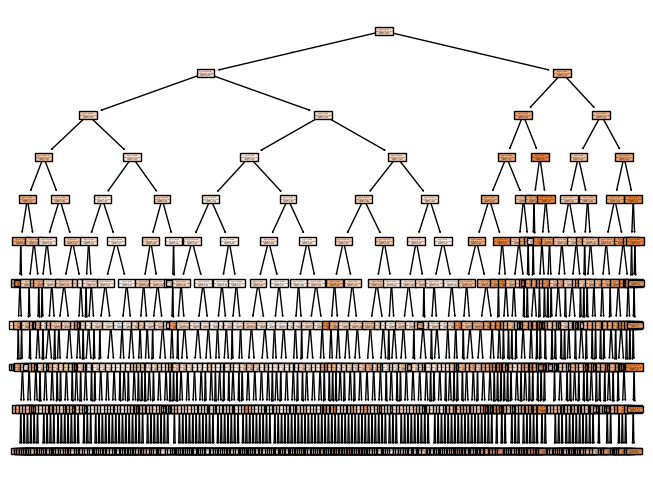

In [29]:
from sklearn import tree
plt.figure(figsize=(8,6))
tree.plot_tree(reg.best_estimator_, filled=True)
plt.plot()

In [30]:
y_pred=reg.best_estimator_.predict(X_test)

In [31]:
r2_score(y_test, y_pred)

0.5646446283521807

In [32]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(max_depth=3)
print(model.max_depth)


3
